In [ ]:

import gymnasium as gym
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

import base64, io, os, glob

# For visualization
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML, display

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)

env = gym.make('CartPole-v1')
env.reset(seed=0)

print('observation space:', env.observation_space)
print('action space:', env.action_space)

device: cuda:0
observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
action space: Discrete(2)


In [3]:
#Learning constants
GAMMA = 0.99
LEARNING_RATE = 0.01
EPISODES_TO_TRAIN = 4

In [4]:
class Policy(nn.Module):
    def __init__(self, state_size=4, action_size=2, hidden_size=32):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        # we just consider 1 dimensional probability of action
        return F.softmax(x, dim=1)

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        model = Categorical(probs)
        action = model.sample()
        return action.item(), model.log_prob(action)

In [5]:
def reinforce(policy, optimizer, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        # gymnasium reset retorna (obs, info)
        state, _ = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            # gymnasium step retorna (obs, reward, terminated, truncated, info)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            rewards.append(reward)
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        R = sum([a * b for a,b in zip(discounts, rewards)])

        # Calculate the loss
        policy_loss = []
        for log_prob in saved_log_probs:
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * R)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores


In [6]:
#Run the code

policy = Policy().to(device)
optimizer = optim.Adam(policy.parameters(), lr=1e-2)
scores = reinforce(policy, optimizer, n_episodes=2000)

Episode 100	Average Score: 47.76
Episode 200	Average Score: 66.42
Episode 300	Average Score: 28.43
Environment solved in 288 episodes!	Average Score: 195.06


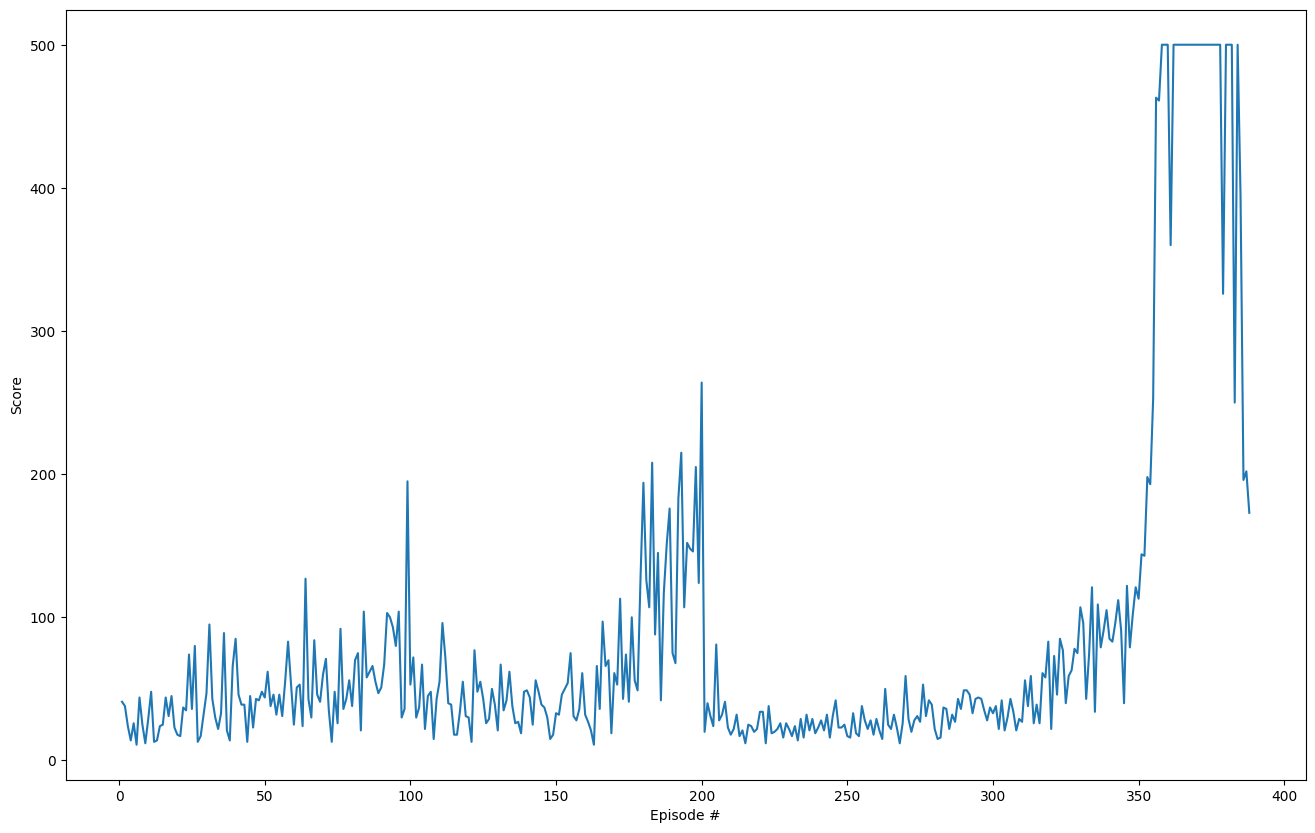

In [7]:
# Plot the learning process
fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(np.arange(1, len(scores)+1), scores)
plt.ylabel('Score')
plt.xlabel('Episode #')
plt.show()


In [8]:
def show_video_of_model(policy, env_name, video_dir='video', name_prefix=None):
    """Graba un episodio del agente usando gymnasium.wrappers.RecordVideo."""
    os.makedirs(video_dir, exist_ok=True)
    name_prefix = name_prefix or env_name.replace('/', '_')
    rec_env = gym.make(env_name, render_mode='rgb_array')
    rec_env = RecordVideo(
        rec_env,
        video_folder=video_dir,
        name_prefix=name_prefix,
        episode_trigger=lambda ep: True,  # graba todos los episodios
    )
    state, _ = rec_env.reset()
    for t in range(1000):
        action, _ = policy.act(state)
        state, reward, terminated, truncated, _ = rec_env.step(action)
        if terminated or truncated:
            break
    rec_env.close()
    return name_prefix


def show_video(name_prefix, video_dir='video'):
    """Embebe el ultimo mp4 generado en el notebook."""
    mp4list = sorted(glob.glob(os.path.join(video_dir, f'{name_prefix}*.mp4')))
    if mp4list:
        mp4 = mp4list[-1]
        with io.open(mp4, 'rb') as fh:
            encoded = base64.b64encode(fh.read()).decode('ascii')
        display(HTML(data=f'''<video alt="test" autoplay loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{encoded}" type="video/mp4" />
             </video>'''))
    else:
        print(f"Could not find video matching {name_prefix}*.mp4 in {video_dir}/")


prefix = show_video_of_model(policy, 'CartPole-v1')
show_video(prefix)

c:\Users\ASUS\Desktop\Andes\Maestria\reinforcement-learning\venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\ASUS\Desktop\Andes\Maestria\reinforcement-learning\CLASE 12\video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
